# 💊 Pill Damage Detection using YOLOv8
**Machine Vision Project**

This notebook trains a YOLOv8 model to detect damaged pills in images and highlights them with bounding boxes.

---
### Dataset Structure Expected
```
pillsdamage/
  ├── train/
  │   ├── images/
  │   └── labels/
  ├── valid/
  │   ├── images/
  │   └── labels/
  └── test/
      ├── images/
      └── labels/
```

## Step 1: Install Dependencies

In [2]:
!pip install ultralytics opencv-python matplotlib Pillow PyYAML -q

^C


ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'C:\\Users\\Sahil Mahadik\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\site-packages\\torchvision\\_C.pyd'
Consider using the `--user` option or check the permissions.



## Step 2: Imports

In [24]:
import os
import cv2
import yaml
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from PIL import Image
from ultralytics import YOLO
import torch
print("All imports successful!")

All imports successful!


## Step 3: Configure Dataset Path
> ⚠️ Update `DATASET_ROOT` to point to your `pillsdamage` folder

In [22]:
# ============================================================
# CONFIGURATION - Update this path
# ============================================================
DATASET_ROOT = "."   # <-- change this if needed
MODEL_SIZE   = "yolov8n"         # nano = fast & good for small datasets
                                  # options: yolov8n, yolov8s, yolov8m
EPOCHS       = 50
IMG_SIZE     = 640
BATCH_SIZE   = 16
PROJECT_NAME = "pill_damage_runs"
RUN_NAME     = "exp1"

# Class names (only one class in your dataset)
CLASS_NAMES = ["damaged_pill"]

# Resolve absolute path
DATASET_ROOT = str(Path(DATASET_ROOT).resolve())
print(f"Dataset root: {DATASET_ROOT}")

Dataset root: C:\Users\Sahil Mahadik\Desktop\MiniProjects\pillsdamage


## Step 4: Verify Dataset & Visualize Samples

In [18]:
def count_dataset_files(root):
    """Count images and labels in each split."""
    splits = ["train", "valid", "test"]
    for split in splits:
        img_dir   = Path(root) / split / "images"
        lbl_dir   = Path(root) / split / "labels"
        img_count = len(list(img_dir.glob("*.*"))) if img_dir.exists() else 0
        lbl_count = len(list(lbl_dir.glob("*.txt"))) if lbl_dir.exists() else 0
        print(f"  [{split:6s}]  images: {img_count:4d}  |  labels: {lbl_count:4d}")

print("Dataset summary:")
count_dataset_files(DATASET_ROOT)

Dataset summary:
  [train ]  images:  538  |  labels:  538
  [valid ]  images:  154  |  labels:  154
  [test  ]  images:   78  |  labels:   78


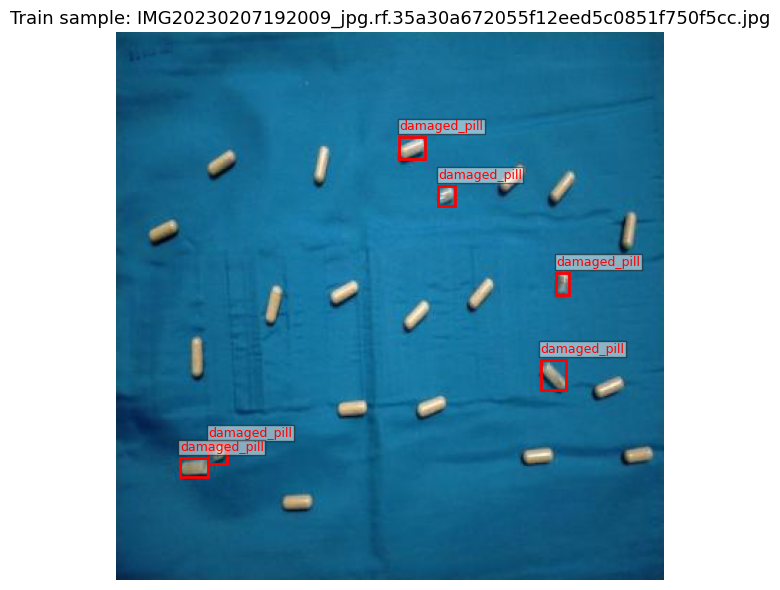

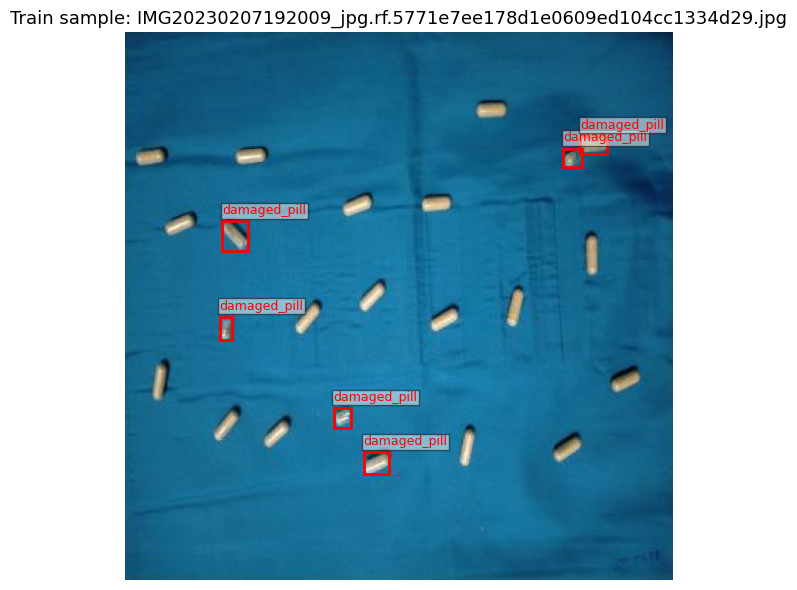

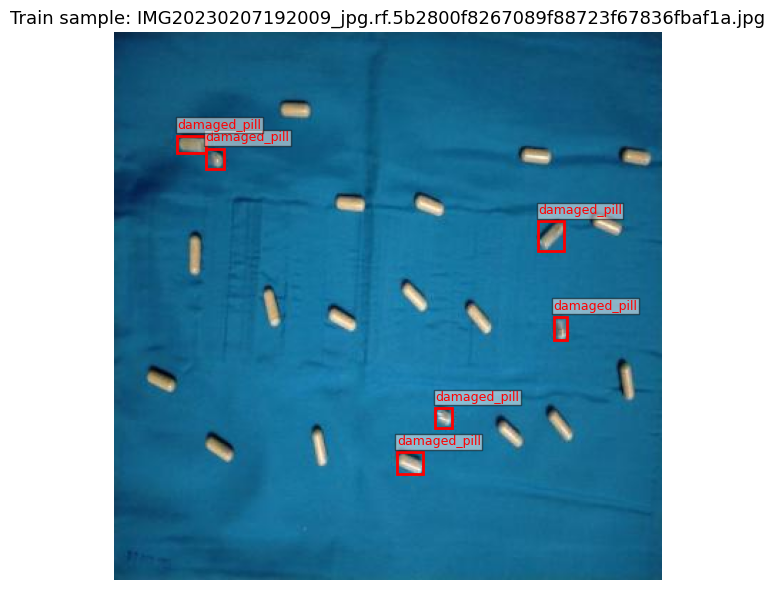

In [19]:
def visualize_sample(image_path, label_path=None, title="Sample"):
    """
    Display an image with YOLO bounding boxes drawn on it.
    Labels are in YOLO format: class cx cy w h (normalized).
    """
    img = np.array(Image.open(image_path).convert("RGB"))
    h, w = img.shape[:2]

    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    ax.imshow(img)
    ax.set_title(title, fontsize=13)
    ax.axis("off")

    if label_path and Path(label_path).exists():
        with open(label_path) as f:
            lines = f.read().strip().splitlines()

        for line in lines:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            cls, cx, cy, bw, bh = int(parts[0]), float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])

            # Convert YOLO (normalized) -> pixel coords
            x1 = int((cx - bw / 2) * w)
            y1 = int((cy - bh / 2) * h)
            box_w = int(bw * w)
            box_h = int(bh * h)

            rect = patches.Rectangle(
                (x1, y1), box_w, box_h,
                linewidth=2, edgecolor="red", facecolor="none"
            )
            ax.add_patch(rect)
            ax.text(x1, y1 - 5, CLASS_NAMES[cls], color="red", fontsize=9,
                    bbox=dict(facecolor="white", alpha=0.5, pad=1))

    plt.tight_layout()
    plt.show()


# Visualize a few training samples
train_img_dir = Path(DATASET_ROOT) / "train" / "images"
train_lbl_dir = Path(DATASET_ROOT) / "train" / "labels"

sample_images = sorted(train_img_dir.glob("*.*"))[:3]

for img_path in sample_images:
    lbl_path = train_lbl_dir / (img_path.stem + ".txt")
    visualize_sample(img_path, lbl_path, title=f"Train sample: {img_path.name}")

## Step 5: Create YAML Config for YOLOv8

In [20]:
yaml_config = {
    "path"  : DATASET_ROOT,
    "train" : "train/images",
    "val"   : "valid/images",
    "test"  : "test/images",
    "nc"    : len(CLASS_NAMES),
    "names" : CLASS_NAMES
}

yaml_path = Path("./pill_damage.yaml")
with open(yaml_path, "w") as f:
    yaml.dump(yaml_config, f, default_flow_style=False)

print(f"YAML config saved to: {yaml_path.resolve()}")
print("\nContents:")
print(open(yaml_path).read())

YAML config saved to: C:\Users\Sahil Mahadik\Desktop\MiniProjects\pillsdamage\pill_damage.yaml

Contents:
names:
- damaged_pill
nc: 1
path: C:\Users\Sahil Mahadik\Desktop\MiniProjects\pillsdamage
test: test/images
train: train/images
val: valid/images



## Step 6: Train YOLOv8 Model

> **Note:** First run downloads the pretrained YOLOv8n weights (~6 MB). Requires internet.

Training augmentations (automatically applied by Ultralytics):
- Mosaic, Flip, HSV shift, Random crop — great for small datasets!

In [25]:
# Load pretrained YOLOv8 nano model (transfer learning)
model = YOLO(f"{MODEL_SIZE}.pt")

# Train
results = model.train(
    data      = str(yaml_path),
    epochs    = EPOCHS,
    imgsz     = IMG_SIZE,
    batch     = BATCH_SIZE,
    project   = PROJECT_NAME,
    name      = RUN_NAME,
    patience  = 15,          # early stopping
    save      = True,
    device    = 0,           # use GPU if available, else 'cpu'
    augment   = True,
    verbose   = True
)

print("\nTraining complete!")
best_model_path = Path(PROJECT_NAME) / RUN_NAME / "weights" / "best.pt"
print(f"Best model saved at: {best_model_path}")

Ultralytics 8.4.23  Python-3.12.3 torch-2.10.0+cpu 


ValueError: Invalid CUDA 'device=0' requested. Use 'device=cpu' or pass valid CUDA device(s) if available, i.e. 'device=0' or 'device=0,1,2,3' for Multi-GPU.

torch.cuda.is_available(): False
torch.cuda.device_count(): 0
os.environ['CUDA_VISIBLE_DEVICES']: 0
See https://pytorch.org/get-started/locally/ for up-to-date torch install instructions if no CUDA devices are seen by torch.


## Step 7: Plot Training Metrics

In [ ]:
results_csv = Path(PROJECT_NAME) / RUN_NAME / "results.csv"

if results_csv.exists():
    import pandas as pd
    df = pd.read_csv(results_csv)
    df.columns = df.columns.str.strip()

    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    fig.suptitle("Training Metrics", fontsize=14)

    metric_pairs = [
        ("train/box_loss",  "val/box_loss",  "Box Loss"),
        ("train/cls_loss",  "val/cls_loss",  "Class Loss"),
        ("train/dfl_loss",  "val/dfl_loss",  "DFL Loss"),
        ("metrics/precision(B)", None,        "Precision"),
        ("metrics/recall(B)",    None,        "Recall"),
        ("metrics/mAP50(B)",     None,        "mAP@0.5"),
    ]

    for ax, (train_col, val_col, label) in zip(axes.flat, metric_pairs):
        if train_col in df.columns:
            ax.plot(df[train_col], label="train", color="royalblue")
        if val_col and val_col in df.columns:
            ax.plot(df[val_col], label="val", color="tomato", linestyle="--")
        ax.set_title(label)
        ax.set_xlabel("Epoch")
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("training_metrics.png", dpi=150)
    plt.show()
else:
    print("results.csv not found. Training may not have completed yet.")

## Step 8: Evaluate on Test Set

In [ ]:
# Load best trained model
best_model_path = Path(PROJECT_NAME) / RUN_NAME / "weights" / "best.pt"
trained_model   = YOLO(str(best_model_path))

# Run validation on test split
test_results = trained_model.val(
    data  = str(yaml_path),
    split = "test",
    imgsz = IMG_SIZE
)

print("\n=== Test Set Evaluation ===")
print(f"  mAP@0.50      : {test_results.box.map50:.4f}")
print(f"  mAP@0.50:0.95 : {test_results.box.map:.4f}")
print(f"  Precision     : {test_results.box.mp:.4f}")
print(f"  Recall        : {test_results.box.mr:.4f}")

## Step 9: Predict & Visualize Damaged Pills
This is the core feature — upload any pill image and damaged pills get highlighted with red bounding boxes.

In [ ]:
def detect_damaged_pills(image_path, model, conf_threshold=0.25, save_output=True):
    """
    Detect and highlight damaged pills in an image.

    Args:
        image_path     : path to the input image
        model          : loaded YOLO model
        conf_threshold : minimum confidence to show a detection
        save_output    : whether to save the annotated image

    Returns:
        annotated image (numpy array)
    """
    image_path = Path(image_path)
    img = cv2.imread(str(image_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Run inference
    results = model.predict(
        source = str(image_path),
        conf   = conf_threshold,
        imgsz  = IMG_SIZE,
        verbose= False
    )

    result      = results[0]
    boxes       = result.boxes
    num_damaged = len(boxes)

    # Draw bounding boxes manually for full control
    annotated = img_rgb.copy()
    for box in boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        conf = float(box.conf[0])
        cls  = int(box.cls[0])

        # Draw red rectangle
        cv2.rectangle(annotated, (x1, y1), (x2, y2), (220, 30, 30), 2)

        # Label with class name + confidence
        label = f"{CLASS_NAMES[cls]} {conf:.2f}"
        (lw, lh), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
        cv2.rectangle(annotated, (x1, y1 - lh - 6), (x1 + lw + 4, y1), (220, 30, 30), -1)
        cv2.putText(annotated, label, (x1 + 2, y1 - 4),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)

    # Display
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    axes[0].imshow(img_rgb)
    axes[0].set_title("Original Image", fontsize=12)
    axes[0].axis("off")

    axes[1].imshow(annotated)
    axes[1].set_title(f"Detected: {num_damaged} Damaged Pill(s)", fontsize=12, color="red")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

    print(f"\n  Image   : {image_path.name}")
    print(f"  Damaged pills detected: {num_damaged}")
    for i, box in enumerate(boxes):
        print(f"    Box {i+1}: confidence = {float(box.conf[0]):.3f}")

    if save_output:
        out_path = f"detected_{image_path.stem}.jpg"
        cv2.imwrite(out_path, cv2.cvtColor(annotated, cv2.COLOR_RGB2BGR))
        print(f"  Saved  : {out_path}")

    return annotated


# Run on all test images
test_img_dir = Path(DATASET_ROOT) / "test" / "images"
test_images  = sorted(test_img_dir.glob("*.*"))[:5]  # show first 5

for img_path in test_images:
    detect_damaged_pills(img_path, trained_model)

## Step 10: Inference on a Custom Image
Upload any pill image and run detection on it.

In [ ]:
# ============================================================
# Change this to your own image path
# ============================================================
custom_image = "./your_pill_image.jpg"   # <-- update this

if Path(custom_image).exists():
    detect_damaged_pills(custom_image, trained_model, conf_threshold=0.25)
else:
    print(f"File not found: {custom_image}")
    print("Update the path to point to your image.")

## Step 11: Batch Detection on a Folder

In [ ]:
def batch_detect(folder_path, model, conf_threshold=0.25):
    """
    Run detection on all images in a folder.
    Prints a summary table.
    """
    folder  = Path(folder_path)
    images  = list(folder.glob("*.jpg")) + list(folder.glob("*.png"))

    print(f"Running detection on {len(images)} images in '{folder}'...\n")
    summary = []

    for img_path in images:
        results = model.predict(source=str(img_path), conf=conf_threshold,
                                imgsz=IMG_SIZE, verbose=False)
        n_damaged = len(results[0].boxes)
        summary.append({"image": img_path.name, "damaged_pills": n_damaged})

    # Print summary
    print(f"{'Image':<40} {'Damaged Pills':>13}")
    print("-" * 55)
    for row in summary:
        flag = " ⚠️" if row["damaged_pills"] > 0 else " ✅"
        print(f"{row['image']:<40} {row['damaged_pills']:>8}{flag}")

    total_damaged = sum(r["damaged_pills"] for r in summary)
    print("-" * 55)
    print(f"Total damaged pills found: {total_damaged}")

    return summary


# Example: run on test folder
summary = batch_detect(Path(DATASET_ROOT) / "test" / "images", trained_model)

## Step 12: Export Model (Optional)
Export to ONNX for deployment or faster CPU inference.

In [ ]:
# Export to ONNX format
trained_model.export(format="onnx", imgsz=IMG_SIZE)
print("Model exported to ONNX format.")

# The .pt file (PyTorch) is already saved at:
print(f"PyTorch model : {best_model_path}")

---
## Summary

| Step | What happened |
|------|---------------|
| Dataset | 700 images, YOLO label format, 1 class: `damaged_pill` |
| Model | YOLOv8n (pretrained on COCO, fine-tuned on your data) |
| Training | 50 epochs, early stopping, data augmentation |
| Output | Bounding boxes around damaged pills with confidence scores |

**Key metrics to report in your college submission:**
- mAP@0.50 (main metric for object detection)
- Precision & Recall
- Inference speed (ms/image)